In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: kaggle


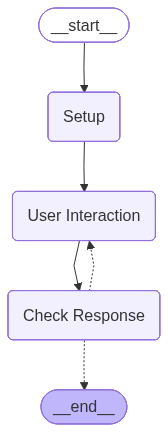

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you tell me the total federal revenue for school districts along with the states they belong to?


/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Provide the total federal revenue for school districts along with the states they belong to",
    "schema_linking": ["studentmathscore_finrev_fed_17", "studentmathscore_finrev_fed_key_17"],
    "answer": "An error occurred while executing the query: ORA-00904: \"SF\".\"STATE\": invalid identifier. Please rephrase your question for better clarity.",
    "sql": "SELECT sf.state, sf.t_fed_rev FROM kaggle.studentmathscore_finrev_fed_17 sf JOIN kaggle.studentmathscore_finrev_fed_key_17 sk ON sf.state_code = sk.state_code"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Provide the total federal revenue for school districts along with the states they belong to",
    "schema_linking": ["studentmathscore_finrev_fed_17", "studentmathscore_finrev_fed_key_17"],
    "answer": "An error occurred while executing the query: ORA-00904: \"SF\".\"STATE\": invalid ident

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[ERROR] Erro ao executar a query: Execution failed on sql 'SELECT sf.state, sf.t_fed_rev FROM kaggle.studentmathscore_finrev_fed_17 sf JOIN kaggle.studentmathscore_finrev_fed_key_17 sk ON sf.state_code = sk.state_code': ORA-00904: "SF"."STATE": invalid identifier
Help: https://docs.oracle.com/error-help/db/ora-00904/
[Conditional Edge] Continuamos a avaliação? True
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  What is the average math score for grade 8 students in these states?
[INFO] O resultado da execução foi: {
    "input": "What is the average math score for grade 8 students in these states?",
    "schema_linking": "",
    "answer": "The question depends on the earlier context, which faced an error in resolving states and their federal revenues. Please clarify and rephrase your question.",
    "sql": ""
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da exec

...

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAP

[INFO] O resultado da execução foi: {
    "input": "Which country and league has hosted the most games?",
    "schema_linking": ["worldsoccerdatabase_football_data"],
    "answer": "The country and league that has hosted the most games is England in the Championship league, with a total of 10,848 games.",
    "sql": "SELECT COUNTRY, LEAGUE, COUNT(*) AS GAME_COUNT FROM KAGGLE.WORLDSOCCERDATABASE_FOOTBALL_DATA GROUP BY COUNTRY, LEAGUE ORDER BY GAME_COUNT DESC FETCH FIRST 1 ROWS ONLY;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which country and league has hosted the most games?",
    "schema_linking": ["worldsoccerdatabase_football_data"],
    "answer": "The country and league that has hosted the most games is England in the Championship league, with a total of 10,848 games.",
    "sql": "SELECT COUNTRY, LEAGUE, COUNT(*) AS GAME_COUNT FROM KAGGLE.WORLDSOCCERDATABASE_FOOTBALL_DATA GROUP BY COUNTRY, L

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAP

[INFO] O resultado da execução foi: {
    "input": "Which country and league hosted the fewest games?",
    "schema_linking": ["worldsoccerdatabase_football_data"],
    "answer": "The country and league that hosted the fewest games is Switzerland in the Super League, with a total of 1,442 games.",
    "sql": "SELECT COUNTRY, LEAGUE, COUNT(*) AS GAME_COUNT FROM KAGGLE.WORLDSOCCERDATABASE_FOOTBALL_DATA GROUP BY COUNTRY, LEAGUE ORDER BY GAME_COUNT ASC FETCH FIRST 1 ROWS ONLY;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which country and league hosted the fewest games?",
    "schema_linking": ["worldsoccerdatabase_football_data"],
    "answer": "The country and league that hosted the fewest games is Switzerland in the Super League, with a total of 1,442 games.",
    "sql": "SELECT COUNTRY, LEAGUE, COUNT(*) AS GAME_COUNT FROM KAGGLE.WORLDSOCCERDATABASE_FOOTBALL_DATA GROUP BY COUNTRY, LEAGUE ORDER BY GA

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
